# Моделирование: прогноз числа покупателей на 7 дней

Сравниваем четыре подхода на одном и том же разбиении по времени: два наивных бейзлайна, Prophet и градиентный бустинг. Все прогнозы и метрики посчитаны командой `make train` (модуль `src/train.py`) и сохранены в `reports/`. Ноутбук читает эти файлы и разбирает результаты, поэтому числа здесь и в README совпадают.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance

from src.data import extend_with_plan, load_calendar, load_plan
from src.features import make_training_dataset, split_x_y
from src.model import build_boosting
from src.train import METHODS, REPORTS_DIR
from src.validation import split_cutoff, time_split

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.1f}'.format)

METHOD_LABELS = {
    'baseline_week_ago': 'Бейзлайн: неделю назад',
    'baseline_two_weeks_ago': 'Бейзлайн: две недели назад',
    'prophet': 'Prophet',
    'boosting': 'Бустинг',
}
DAY_LABELS = {
    i: f'{name} ({i})'
    for i, name in enumerate(
        [
            'Понедельник',
            'Вторник',
            'Среда',
            'Четверг',
            'Пятница',
            'Суббота',
            'Воскресенье',
        ],
        start=1,
    )
}

predictions = pd.read_csv(
    REPORTS_DIR / 'predictions.csv',
    parse_dates=['date', 'target_date', 'cutoff'],
)
metrics = pd.read_csv(
    REPORTS_DIR / 'metrics.csv', dtype={'horizon': str, 'store_id': str}
)
coverage = pd.read_csv(REPORTS_DIR / 'coverage.csv', dtype={'store_id': str})
HOLDOUT_FOLD = int(predictions['fold'].max())
holdout = predictions[predictions['fold'] == HOLDOUT_FOLD]

## Схема валидации

- Строка - магазин и момент прогноза D. Модель горизонта h прогнозирует число покупателей в день D+h, по одной модели на каждый горизонт 1-7.
- 4 окна по 6 недель, последнее окно - holdout. В каждом окне модели обучаются только на ответах, известных к первому прогнозу окна (зазор в `time_split`), поэтому ни один прогноз не делает модель, видевшая будущее относительно момента прогноза.
- Бустинг и бейзлайны используют признаки на момент D. Prophet переобучается для каждого D на истории по D включительно: так он в тех же условиях, что и бустинг.
- Все методы оцениваются на одних и тех же строках: открытые дни с известным ответом. Закрытые по графику дни прогнозируются как 0 и в метрики не входят.

In [3]:
predictions.groupby('fold').agg(
    cutoff=('cutoff', 'first'),
    first_answer=('target_date', 'min'),
    last_answer=('target_date', 'max'),
    rows=('y', 'size'),
).rename(
    columns={
        'cutoff': 'Граница',
        'first_answer': 'Первый ответ',
        'last_answer': 'Последний ответ',
        'rows': 'Строк (все горизонты)',
    }
)

,Граница,Первый ответ,Последний ответ,Строк (все горизонты)
fold,,,,
1,2015-02-13,2015-02-14,2015-03-27,504
2,2015-03-27,2015-03-28,2015-05-08,462
3,2015-05-08,2015-05-09,2015-06-19,462
4,2015-06-19,2015-06-20,2015-07-31,504


## Holdout: сравнение методов

MAE - ошибка в покупателях за день, MAPE - в процентах. Все горизонты вместе.

In [4]:
pooled = metrics[
    (metrics['fold'] == HOLDOUT_FOLD) & (metrics['horizon'] == 'все')
]
(
    pooled.pivot_table(
        index='model', columns='store_id', values=['MAE', 'MAPE, %']
    )
    .loc[METHODS]
    .rename(index=METHOD_LABELS)
)

MAE           MAPE, %         
store_id                      1   20  все       1  20  все
model                                                     
Бейзлайн: неделю назад     69.2 86.7 77.9    13.7 9.8 11.7
Бейзлайн: две недели назад 36.2 61.3 48.7     7.0 6.8  6.9
Prophet                    34.6 52.3 43.5     6.8 5.9  6.4
Бустинг                    25.3 45.9 35.6     5.1 5.4  5.2

**Вывод.** На holdout бустинг точнее всех: MAE 35.6 покупателя в день (MAPE 5.2%) против 43.5 (6.4%) у Prophet и 48.7 (6.9%) у лучшего бейзлайна. Выигрыш есть у обоих магазинов: у магазина 1 MAE 25.3 против 36.2 у бейзлайна «две недели назад», у магазина 20 - 45.9 против 61.3. Бейзлайн «неделю назад» заметно хуже бейзлайна «две недели назад» (77.9 против 48.7): это промо через неделю, найденное в EDA.

### Ошибка по горизонтам

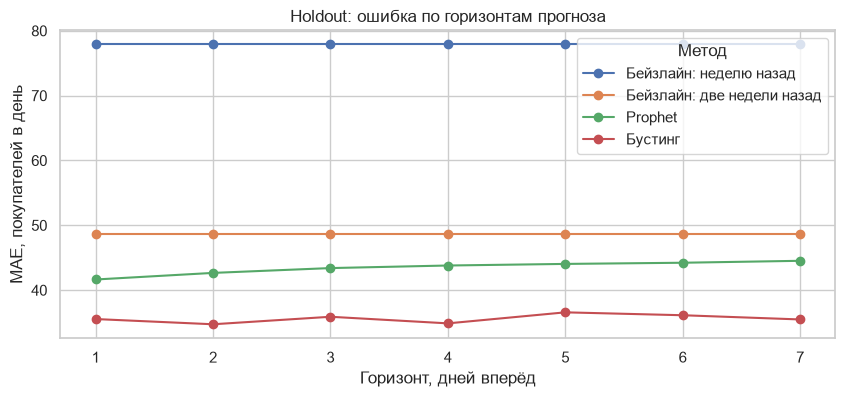

model,Бейзлайн: неделю назад,Бейзлайн: две недели назад,Prophet,Бустинг
horizon,,,,
1,77.9,48.7,41.6,35.5
2,77.9,48.7,42.7,34.7
3,77.9,48.7,43.4,35.9
4,77.9,48.7,43.8,34.9
5,77.9,48.7,44.0,36.6
6,77.9,48.7,44.2,36.1
7,77.9,48.7,44.5,35.5


In [5]:
by_horizon = (
    metrics[
        (metrics['fold'] == HOLDOUT_FOLD)
        & (metrics['store_id'] == 'все')
        & (metrics['horizon'] != 'все')
    ]
    .astype({'horizon': int})
    .pivot_table(index='horizon', columns='model', values='MAE')[METHODS]
    .rename(columns=METHOD_LABELS)
)
ax = by_horizon.plot(marker='o', figsize=(10, 4))
ax.set(
    title='Holdout: ошибка по горизонтам прогноза',
    xlabel='Горизонт, дней вперёд',
    ylabel='MAE, покупателей в день',
)
ax.legend(title='Метод')
plt.show()

by_horizon

**Вывод.** У бустинга ошибка почти не зависит от горизонта: от 34.7 до 36.6 на всех семи горизонтах. У Prophet она растёт с 41.6 на горизонте 1 до 44.5 на горизонте 7. Бейзлайны от горизонта не зависят вовсе: они берут тот же день недели в прошлом, и он одинаков для любого момента прогноза.

**Что это значит:** прогноз на неделю вперёд почти так же надёжен, как на завтра, поэтому смены и закупки можно планировать сразу на неделю.

## Бэктест: устойчивость по окнам

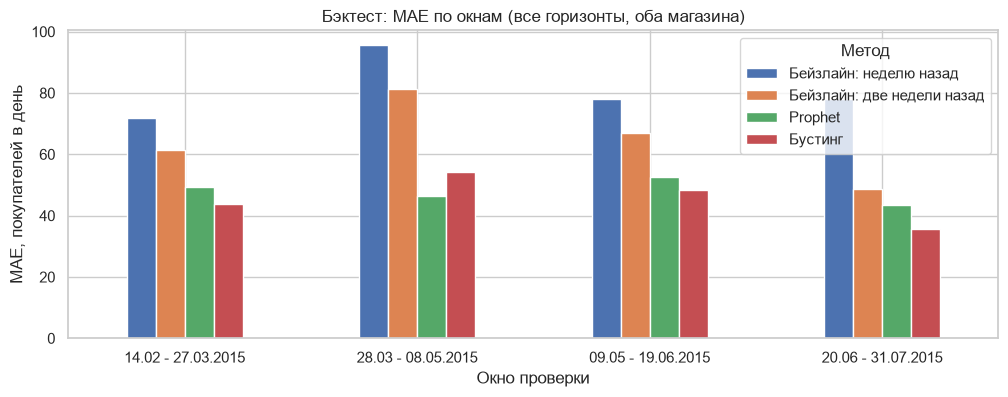

fold,14.02 - 27.03.2015,28.03 - 08.05.2015,09.05 - 19.06.2015,20.06 - 31.07.2015,Среднее,Ст. откл.
model,,,,,,
Бейзлайн: неделю назад,71.8,95.7,77.9,77.9,80.8,10.3
Бейзлайн: две недели назад,61.3,81.3,67.1,48.7,64.6,13.5
Prophet,49.3,46.4,52.6,43.5,48.0,3.9
Бустинг,44.0,54.1,48.3,35.6,45.5,7.8


In [6]:
periods = predictions.groupby('fold')['target_date'].agg(['min', 'max'])
fold_labels = {
    fold: f'{row["min"]:%d.%m} - {row["max"]:%d.%m.%Y}'
    for fold, row in periods.to_dict('index').items()
}
by_fold = (
    metrics[(metrics['horizon'] == 'все') & (metrics['store_id'] == 'все')]
    .pivot_table(index='fold', columns='model', values='MAE')[METHODS]
    .rename(index=fold_labels, columns=METHOD_LABELS)
)
ax = by_fold.plot.bar(figsize=(12, 4), rot=0)
ax.set(
    title='Бэктест: MAE по окнам (все горизонты, оба магазина)',
    xlabel='Окно проверки',
    ylabel='MAE, покупателей в день',
)
ax.legend(title='Метод')
plt.show()

by_fold.T.assign(mean=by_fold.mean(), std=by_fold.std()).rename(
    columns={'mean': 'Среднее', 'std': 'Ст. откл.'}
)

**Вывод.** Бустинг лучше бейзлайнов во всех четырёх окнах. Prophet он обыгрывает в трёх окнах из четырёх, а в окне 28.03 - 08.05.2015 Prophet точнее (46.4 против 54.1). В среднем по окнам бустинг точнее Prophet ненамного: 45.5 против 48.0, при этом у Prophet разброс между окнами меньше (стандартное отклонение 3.9 против 7.8).

Holdout оказался самым удачным окном для бустинга, поэтому честная оценка его качества - среднее по бэктесту, а не одно число holdout.

## Прогноз и факт на holdout

Горизонт 7 дней, самый дальний. Серая полоса - интервал бустинга между квантилями 0.1 и 0.9.

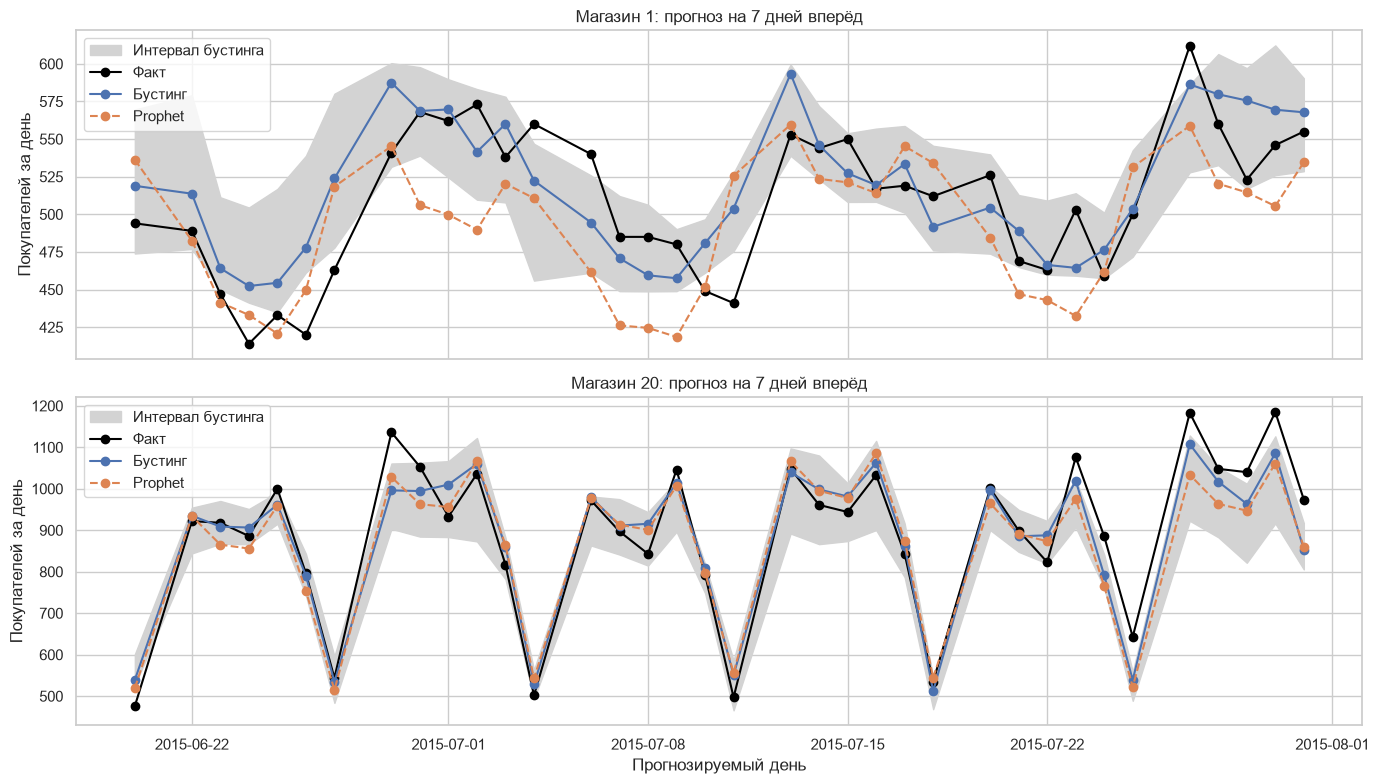

In [7]:
farthest = holdout[holdout['horizon'] == holdout['horizon'].max()]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (store, rows) in zip(axes, farthest.groupby('store_id'), strict=True):
    rows = rows.set_index('target_date').sort_index()
    ax.fill_between(
        rows.index,
        rows['lower'],
        rows['upper'],
        color='lightgrey',
        label='Интервал бустинга',
    )
    ax.plot(rows.index, rows['y'], 'o-', color='black', label='Факт')
    ax.plot(rows.index, rows['boosting'], 'o-', label='Бустинг')
    ax.plot(rows.index, rows['prophet'], 'o--', label='Prophet')
    ax.set(
        title=f'Магазин {store}: прогноз на 7 дней вперёд',
        ylabel='Покупателей за день',
    )
    ax.legend(loc='upper left')
axes[-1].set_xlabel('Прогнозируемый день')
plt.tight_layout()
plt.show()

**Вывод.** У магазина 20 обе модели хорошо повторяют недельный профиль с провалом в субботу, а главные промахи - отдельные дни, где факт резко выше обычного, например в конце июля. У магазина 1 недельный профиль слабый, и на нескольких неделях Prophet заметно занижает прогноз (например, 6-10 июля), а бустинг ближе к факту. Часть фактов выходит за серую полосу: интервал уже, чем нужно, это разобрано ниже.

## Какие признаки важны

Permutation importance: на holdout по очереди перемешиваем один признак и смотрим, насколько растёт MAE. Чем больше рост, тем сильнее модель опирается на признак. Модели обучены только на train, как в валидации. Смотрим самый близкий и самый дальний горизонт.

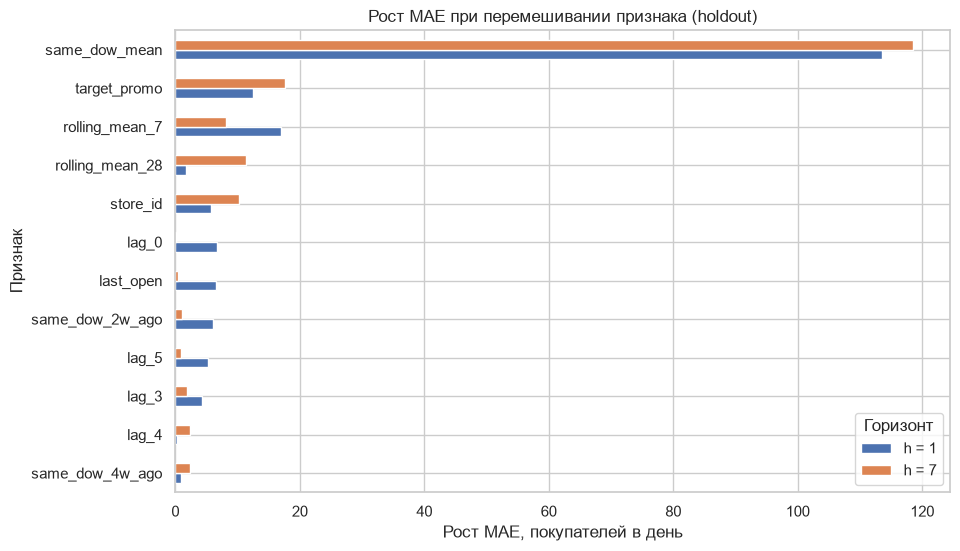

,h = 1,h = 7
same_dow_mean,113.6,118.6
target_promo,12.5,17.7
rolling_mean_7,16.9,8.1
rolling_mean_28,1.7,11.3
store_id,5.8,10.2
lag_0,6.7,0.2
last_open,6.5,0.4
same_dow_2w_ago,6.0,1.0
lag_5,5.2,0.9
lag_3,4.3,1.9


In [8]:
training_sets = make_training_dataset(
    extend_with_plan(load_calendar(), load_plan())
)
cutoff = split_cutoff(training_sets[1])
importance = {}
for horizon in (1, 7):
    train, holdout_rows = time_split(training_sets[horizon], cutoff)
    model = build_boosting().fit(*split_x_y(train))
    x_holdout, y_holdout = split_x_y(holdout_rows)
    result = permutation_importance(
        model,
        x_holdout,
        y_holdout,
        scoring='neg_mean_absolute_error',
        n_repeats=20,
        random_state=42,
    )
    importance[f'h = {horizon}'] = pd.Series(
        result.importances_mean, index=x_holdout.columns
    )

importance = pd.DataFrame(importance)
top = importance.loc[
    importance.max(axis=1).sort_values(ascending=False).index[:12]
]
ax = top.iloc[::-1].plot.barh(figsize=(10, 6))
ax.set(
    title='Рост MAE при перемешивании признака (holdout)',
    xlabel='Рост MAE, покупателей в день',
    ylabel='Признак',
)
ax.legend(title='Горизонт')
plt.show()

top

**Вывод.** Главный признак на обоих горизонтах - `same_dow_mean`, среднее за тот же день недели по последним 4 неделям: без него MAE растёт на 113.6 (h = 1) и 118.6 (h = 7) покупателя. Следом идёт промо на прогнозируемый день (`target_promo`: 12.5 и 17.7).

Дальше горизонты расходятся. Прогнозу на завтра нужны свежие данные: `rolling_mean_7` (16.9), `lag_0` (6.7), `last_open` (6.5). Прогнозу на неделю вперёд - более длинный уровень `rolling_mean_28` (11.3) и магазин `store_id` (10.2), а вчерашний день ему почти не нужен (`lag_0` - 0.2).

**Что это значит:** модель опирается на те же факторы, что нашёл EDA - недельный профиль магазина, промо и текущий уровень. Поэтому ошибка и не растёт с горизонтом: недельный профиль и промо на прогнозируемый день известны одинаково хорошо и на завтра, и на неделю вперёд.

## Разбор ошибок

Берём все 4 окна, чтобы примеров было больше. Ошибка бустинга - прогноз минус факт.

In [9]:
errors = predictions.assign(
    error=predictions['boosting'] - predictions['y'],
    abs_error=(predictions['boosting'] - predictions['y']).abs(),
    ape=(predictions['boosting'] - predictions['y']).abs()
    / predictions['y']
    * 100,
)
(
    errors.groupby(['target_dow', 'target_promo'])[
        ['abs_error', 'ape', 'error']
    ]
    .mean()
    .rename(index=DAY_LABELS, level='target_dow')
    .rename_axis(['День недели', 'Промо'])
    .rename(
        columns={
            'abs_error': 'MAE',
            'ape': 'MAPE, %',
            'error': 'Средний сдвиг',
        }
    )
)

MAE  MAPE, %  Средний сдвиг
День недели     Промо                             
Понедельник (1) 0.0   33.2      5.2            0.3
                1.0   46.4      6.3            0.8
Вторник (2)     0.0   41.1      5.8          -19.4
                1.0   60.4      8.1           17.9
Среда (3)       0.0   31.4      5.0           10.0
                1.0   59.1      7.9            6.4
Четверг (4)     0.0   42.8      6.8            3.6
                1.0   54.0      7.2           -0.4
Пятница (5)     0.0   39.8      7.2           11.5
                1.0   40.6      6.0           10.6
Суббота (6)     0.0   42.9      7.7           -2.1

**Вывод.** Промо-дни прогнозировать труднее: MAE в промо-дни выше, чем в те же дни недели без промо, сильнее всего во вторник и среду (60.4 и 59.1 против 41.1 и 31.4). Систематического сдвига почти нет: в большинстве групп средняя ошибка близка к нулю. Заметнее всего вторник: без промо прогноз в среднем ниже факта на 19.4, с промо выше на 17.9.

In [10]:
calendar = load_calendar()
holiday_dates = pd.DataFrame(
    {
        'holiday_date': calendar.loc[
            calendar['state_holiday'].isin(['a', 'b', 'c']), 'date'
        ]
        .drop_duplicates()
        .sort_values()
    }
)
nearest = pd.merge_asof(
    errors.sort_values('target_date'),
    holiday_dates,
    left_on='target_date',
    right_on='holiday_date',
    direction='nearest',
)
nearest['days_to_holiday'] = (
    nearest['target_date'] - nearest['holiday_date']
).dt.days
near = nearest['days_to_holiday'].abs() <= 3
print(
    'MAE бустинга: в пределах 3 дней от госпраздника',
    round(nearest.loc[near, 'abs_error'].mean(), 1),
    f'({near.sum()} строк), в остальные дни',
    round(nearest.loc[~near, 'abs_error'].mean(), 1),
    f'({(~near).sum()} строк)',
)

worst = nearest.nlargest(10, 'abs_error')[
    [
        'store_id',
        'fold',
        'horizon',
        'target_date',
        'target_dow',
        'target_promo',
        'y',
        'boosting',
        'prophet',
        'days_to_holiday',
    ]
]
worst.assign(target_dow=worst['target_dow'].map(DAY_LABELS))

MAE бустинга: в пределах 3 дней от госпраздника 58.7 (378 строк), в остальные дни 42.0 (1554 строк)


,store_id,fold,horizon,target_date,target_dow,target_promo,y,boosting,prophet,days_to_holiday
41,20,1,2,2015-02-17,Вторник (2),1.0,657.0,908.9,902.7,42
578,1,2,6,2015-04-04,Суббота (6),0.0,796.0,550.5,692.2,1
35,20,1,1,2015-02-17,Вторник (2),1.0,657.0,902.3,901.0,42
37,20,1,3,2015-02-17,Вторник (2),1.0,657.0,900.1,902.7,42
843,20,2,7,2015-04-28,Вторник (2),1.0,772.0,1013.3,981.2,-3
575,1,2,7,2015-04-04,Суббота (6),0.0,796.0,557.0,692.2,1
1359,20,3,4,2015-06-15,Понедельник (1),1.0,842.0,1080.3,1041.5,11
1368,20,3,2,2015-06-15,Понедельник (1),1.0,842.0,1077.0,1043.5,11
577,1,2,5,2015-04-04,Суббота (6),0.0,796.0,564.8,696.3,1
36,20,1,7,2015-02-17,Вторник (2),1.0,657.0,887.5,890.9,42


**Вывод.** В пределах 3 дней от госпраздника ошибка бустинга заметно выше: MAE 58.7 против 42.0 в остальные дни. Среди 10 худших прогнозов:

- **2015-04-04, магазин 1** - Пасхальная суббота, на следующий день после госпраздника. Факт 796, бустинг прогнозировал 550.5-564.8, Prophet 692.2-696.3: у Prophet Пасха задана событием с окном вокруг даты.
- **2015-04-28, магазин 20** - за 3 дня до 1 мая, бустинг завысил прогноз.
- **2015-02-17 и 2015-06-15, магазин 20** - до ближайшего госпраздника 42 и 11 дней, и Prophet ошибся так же, как бустинг. Причины в данных нет. 17 февраля 2015 года - вторник карнавала (Fastnacht), вероятно, дело в нём, но такого признака у нас нет.

**Что это значит:** одного признака «завтра госпраздник» мало. Нужны окна вокруг праздников, как у Prophet: канун, день после праздника, пасхальная неделя.

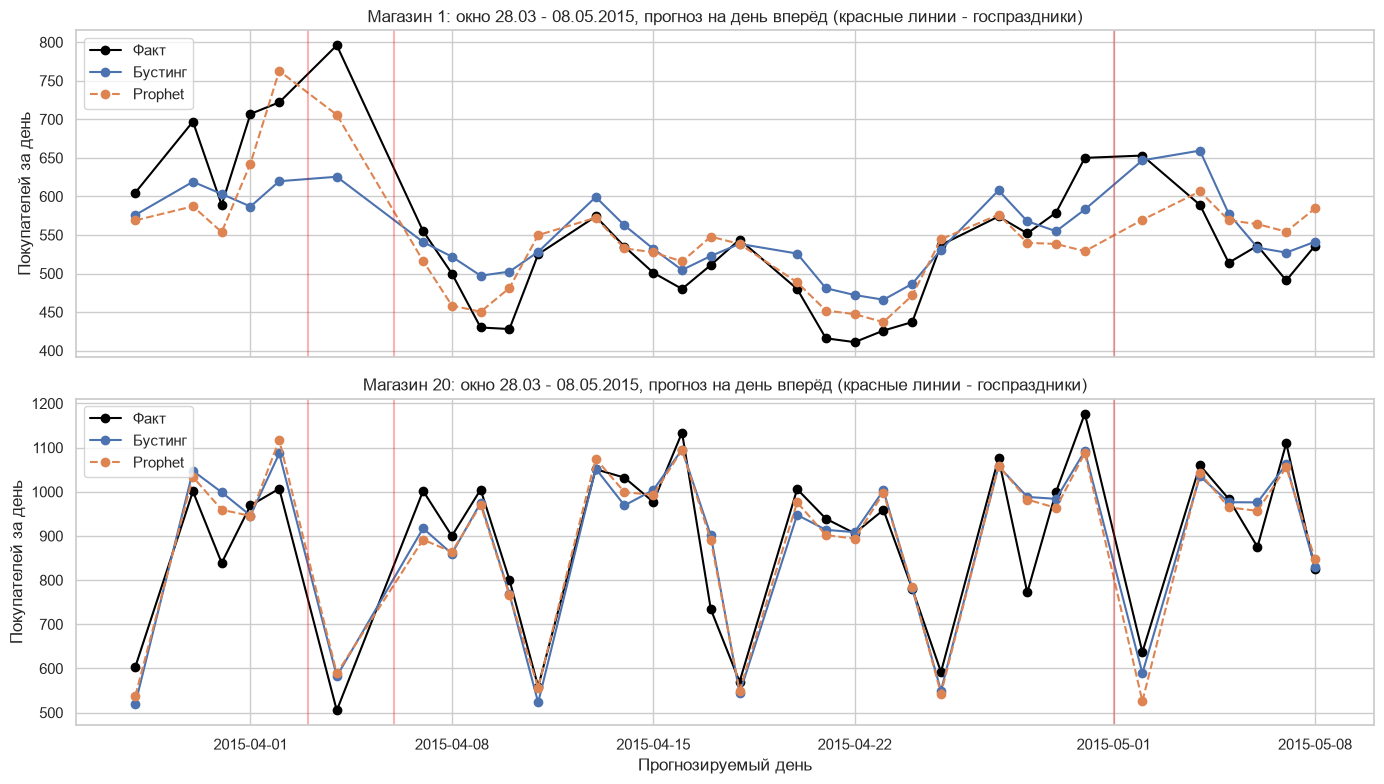

In [11]:
easter = predictions[
    (predictions['fold'] == 2) & (predictions['horizon'] == 1)
]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (store, rows) in zip(axes, easter.groupby('store_id'), strict=True):
    rows = rows.set_index('target_date').sort_index()
    ax.plot(rows.index, rows['y'], 'o-', color='black', label='Факт')
    ax.plot(rows.index, rows['boosting'], 'o-', label='Бустинг')
    ax.plot(rows.index, rows['prophet'], 'o--', label='Prophet')
    for day in holiday_dates['holiday_date']:
        if rows.index.min() <= day <= rows.index.max():
            ax.axvline(day, color='red', alpha=0.3)
    ax.set(
        title=f'Магазин {store}: окно 28.03 - 08.05.2015, прогноз на день вперёд (красные линии - госпраздники)',
        ylabel='Покупателей за день',
    )
    ax.legend(loc='upper left')
axes[-1].set_xlabel('Прогнозируемый день')
plt.tight_layout()
plt.show()

**Вывод.** Это окно с Пасхой (госпраздники 3 и 6 апреля 2015 года) и 1 мая - единственное, где Prophet точнее бустинга. На графике видно почему: перед Страстной пятницей и в Пасхальную субботу у магазина 1 поток резко растёт. Prophet, у которого Пасха задана событием с окном в 2 дня до и 1 день после, этот рост ловит, а бустинг почти нет. Перед 1 мая, наоборот, бустинг у магазина 1 ближе к факту. У магазина 20 обе модели ведут себя похоже.

## Интервал неопределённости

Интервал между квантилями 0.1 и 0.9 должен накрывать около 80% фактических значений.

In [12]:
width = predictions.assign(width=predictions['upper'] - predictions['lower'])
print(
    'Средняя ширина интервала, покупателей:',
    width.groupby('store_id')['width'].mean().round(1).to_dict(),
)
coverage.pivot_table(
    index='store_id', columns='fold', values='coverage, %'
).rename(columns=fold_labels)

Средняя ширина интервала, покупателей: {1: 93.0, 20: 139.3}


fold,14.02 - 27.03.2015,28.03 - 08.05.2015,09.05 - 19.06.2015,20.06 - 31.07.2015
store_id,,,,
1,62.7,44.2,61.9,71.4
20,65.5,70.1,64.1,65.9


**Вывод.** Интервал уже, чем заявлено: вместо примерно 80% он накрывает от 61.9% до 71.4% фактов, а у магазина 1 в окне с Пасхой - только 44.2%. Средняя ширина интервала - 93.0 покупателя у магазина 1 и 139.3 у магазина 20.

Квантильные модели учатся на тех же данных, что и основная, и недооценивают свою ошибку на новых периодах. Исправить это можно калибровкой на отложенном периоде (conformal prediction). В текущей версии интервал стоит читать как типичный разброс, а не как гарантию 80%.

## Итоги

- **Бустинг - лучший метод:** MAE 35.6 покупателя в день на holdout и 45.5 в среднем по 4 окнам бэктеста. Оба бейзлайна он обыгрывает во всех окнах, Prophet - в трёх из четырёх.
- **Ошибка почти не растёт с горизонтом:** прогноз на неделю вперёд почти так же точен, как на завтра.
- **Модель опирается на понятные факторы:** недельный профиль магазина (`same_dow_mean`), промо и недавний уровень - те же, что нашёл EDA.
- **Слабое место - дни вокруг праздников:** MAE 58.7 против 42.0 в обычные дни, особенно Пасха. Здесь Prophet с окнами вокруг праздников точнее.
- **Интервал узковат:** накрывает около двух третей фактов вместо 80%.

**Что улучшить:** признаки окон вокруг праздников, как в Prophet; калибровка интервала; признак региональных событий вроде карнавала.